In [2]:
import json
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
with open("scores.json", 'r') as f:
    scores = json.load(f)

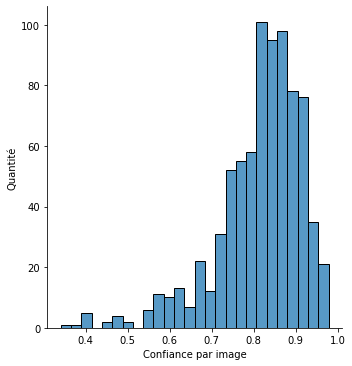

In [4]:
ax = sns.displot(scores)
ax.set(xlabel='Confiance par image', ylabel="Quantité")
plt.show()

In [13]:
df_scores = pd.DataFrame(scores)
df_scores.describe()

,0
count,796.000000
mean,0.813362
std,0.102472
min,0.340116
25%,0.768813
50%,0.832795
75%,0.883297
max,0.978045


In [6]:
with open("sitcom scene.json", 'r') as f:
    sitcom = json.load(f)

In [8]:
nbImages = len(sitcom['images'])
nbImages

741

In [7]:
catByID = {}
for cat in sitcom['categories']:
    catByID[cat['id']] = cat['name']
catByID

{1: 'person',
 2: 'head',
 3: 'lfoot',
 4: 'lhand',
 5: 'llarm',
 6: 'llleg',
 7: 'luarm',
 8: 'luleg',
 9: 'rfoot',
 10: 'rhand',
 11: 'rlarm',
 12: 'rlleg',
 13: 'ruarm',
 14: 'ruleg',
 15: 'torso'}

In [8]:
stat = {}
for ann in sitcom['annotations']:
    category_name = catByID[ann["category_id"]]
    if catByID[ann["category_id"]] in stat:
        stat[category_name]["count"]+=1
        try:
            stat[category_name]["totalArea"]+=ann["area"]
        except:
            stat[category_name]["totalArea"]+=ann["bbox"][2]*ann["bbox"][3]
    else:
        stat[category_name]={}
        stat[category_name]["count"] = 1
        stat[category_name]["totalArea"] = ann["area"]

for each in stat:
    stat[each]["meanArea"] = stat[each]["totalArea"]/stat[each]["count"]
    stat[each]["countByImage"] = stat[each]["count"]/nbImages

In [15]:
df = pd.DataFrame.from_dict(stat).transpose()
df

,count,totalArea,meanArea,countByImage
person,3149.0,7.113988e+07,22591.261035,4.249663
luarm,1240.0,1.638937e+06,1321.723504,1.673414
llarm,932.0,7.940611e+05,851.996863,1.257760
ruarm,1077.0,1.372550e+06,1274.419462,1.453441
rlarm,855.0,6.355329e+05,743.313350,1.153846
ruleg,769.0,8.329565e+05,1083.168411,1.037787
rlleg,560.0,6.421529e+05,1146.701573,0.755735
luleg,745.0,8.726732e+05,1171.373369,1.005398
torso,1457.0,7.864835e+06,5397.964997,1.966262
rfoot,460.0,1.199840e+05,260.834783,0.620783


In [16]:
df = df.sort_values("countByImage", ascending=0).drop("totalArea", axis=1)
df

,count,meanArea,countByImage
person,3149.0,22591.261035,4.249663
head,2032.0,1902.314961,2.742240
torso,1457.0,5397.964997,1.966262
luarm,1240.0,1321.723504,1.673414
ruarm,1077.0,1274.419462,1.453441
rhand,940.0,418.560638,1.268556
llarm,932.0,851.996863,1.257760
lhand,910.0,444.667033,1.228070
rlarm,855.0,743.313350,1.153846
ruleg,769.0,1083.168411,1.037787


In [18]:
df.to_csv('stats.csv')